# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [1]:
!git clone https://github.com/VietAnh-AI2-UET/K4-DAY02-BuiVietAnh-2A202602611.git

Cloning into 'K4-DAY02-BuiVietAnh-2A202602611'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 94 (delta 8), reused 9 (delta 6), pack-reused 73 (from 2)
Receiving objects: 100% (94/94), 16.53 MiB | 28.02 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [2]:
%cd /kaggle/working/K4-DAY02-BuiVietAnh-2A202602611/submissions/2A202602611_BuiVietAnh/code

/kaggle/working/K4-DAY02-BuiVietAnh-2A202602611/submissions/2A202602611_BuiVietAnh/code


In [3]:
!pwd

/kaggle/working/K4-DAY02-BuiVietAnh-2A202602611/submissions/2A202602611_BuiVietAnh/code


In [4]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
!pip -q install timm openpyxl fvcore

import sys, os, platform
import numpy as np, pandas as pd, torch, timm

# Tìm repo dù mở notebook từ workspace, thư mục repo hay thư mục code.
from pathlib import Path
current_dir = Path.cwd().resolve()
candidates = [current_dir, *current_dir.parents]
candidates += [parent / "K4-DAY02-BuiVietAnh-2A202602611" for parent in [current_dir, *current_dir.parents]]
repo_path = next((p for p in candidates
                  if (p / "eval.py").is_file()
                  and (p / "submissions/2A202602611_BuiVietAnh/code/train.py").is_file()), None)
if repo_path is None:
    raise FileNotFoundError("Không tìm thấy repo bài lab chứa eval.py; kiểm tra vị trí clone repo")
REPO_DIR = str(repo_path)
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, str(repo_path / "submissions/2A202602611_BuiVietAnh/code"))
print("Repo:", REPO_DIR)

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 4.5 MB/s eta 0:00:00
Repo: /kaggle/working/K4-DAY02-BuiVietAnh-2A202602611
python 3.13.15 | torch 2.11.0+cu128 | timm 1.0.29
GPU: Tesla T4


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [5]:
import os
import hashlib
import shutil
from pathlib import Path

os.makedirs("data/images", exist_ok=True)
os.makedirs("data/labels", exist_ok=True)

if not os.path.exists("data/images.zip"):
    !wget -q -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"

# Kiểm tra file ZIP có đúng nội dung hay không
h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)

assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", \
    f"MD5 sai: {h.hexdigest()}"

# Chuyển các ảnh đã giải nén vào data/ ở lần chạy trước
for image in Path("data").glob("*.jpg"):
    destination = Path("data/images") / image.name
    if not destination.exists():
        shutil.move(str(image), str(destination))

# Giải nén vào đúng thư mục, bỏ qua các file đã tồn tại
!unzip -q -n data/images.zip -d data/images/

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    !wget -q -O data/labels/{name}.csv "{BASE}/{name}.csv"

# Kiểm tra kết quả
images = sorted(Path("data/images").glob("*.jpg"))
print(f"Số ảnh trong data/images: {len(images)}")
print("10 ảnh đầu:")
for image in images[:10]:
    print(image.name)

!ls -la data/labels

Số ảnh trong data/images: 17509
10 ảnh đầu:
20160928-140314-0.jpg
20160928-140337-0.jpg
20160928-140731-0.jpg
20160928-140747-0.jpg
20160928-141107-0.jpg
20160928-141135-0.jpg
20160928-141355-0.jpg
20160928-141421-0.jpg
20160928-141437-0.jpg
20160928-142056-0.jpg
total 1012
drwxr-xr-x 2 root root   4096 Oct  6 02:32 .
drwxr-xr-x 4 root root   4096 Oct  6 02:30 ..
-rw-r--r-- 1 root root 598898 Oct  6 02:32 labels.csv
-rw-r--r-- 1 root root  84183 Oct  6 02:32 test_subset0.csv
-rw-r--r-- 1 root root 252039 Oct  6 02:32 train_subset0.csv
-rw-r--r-- 1 root root  84039 Oct  6 02:32 val_subset0.csv


In [6]:
IMAGES_DIR = "data/images"   # Thư mục chứa các file ảnh
LABELS_DIR = "data/labels"

## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         644   215   215
Snake Weed        609   203   204
Negatives        5463  1821  1822
Tổng: 17,509 ảnh; giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}


,train,val,test,Total
Class,,,,
Chinee Apple,675,225,226,1126
Lantana,637,213,213,1063
Parkinsonia,618,206,207,1031
Parthenium,613,204,205,1022
Prickly Acacia,637,212,213,1062
Rubber Vine,605,202,202,1009
Siam Weed,644,215,215,1074
Snake Weed,609,203,204,1016
Negatives,5463,1821,1822,9106


,Observed,Table 1,Difference
Class,,,
Chinee Apple,1126,1125,1
Lantana,1063,1064,-1
Parkinsonia,1031,1031,0
Parthenium,1022,1022,0
Prickly Acacia,1062,1062,0
Rubber Vine,1009,1009,0
Siam Weed,1074,1074,0
Snake Weed,1016,1016,0
Negatives,9106,9106,0


Counts differ from Table 1; check the source CSVs before training.
Negatives account for 52.01%; the class distribution is imbalanced.


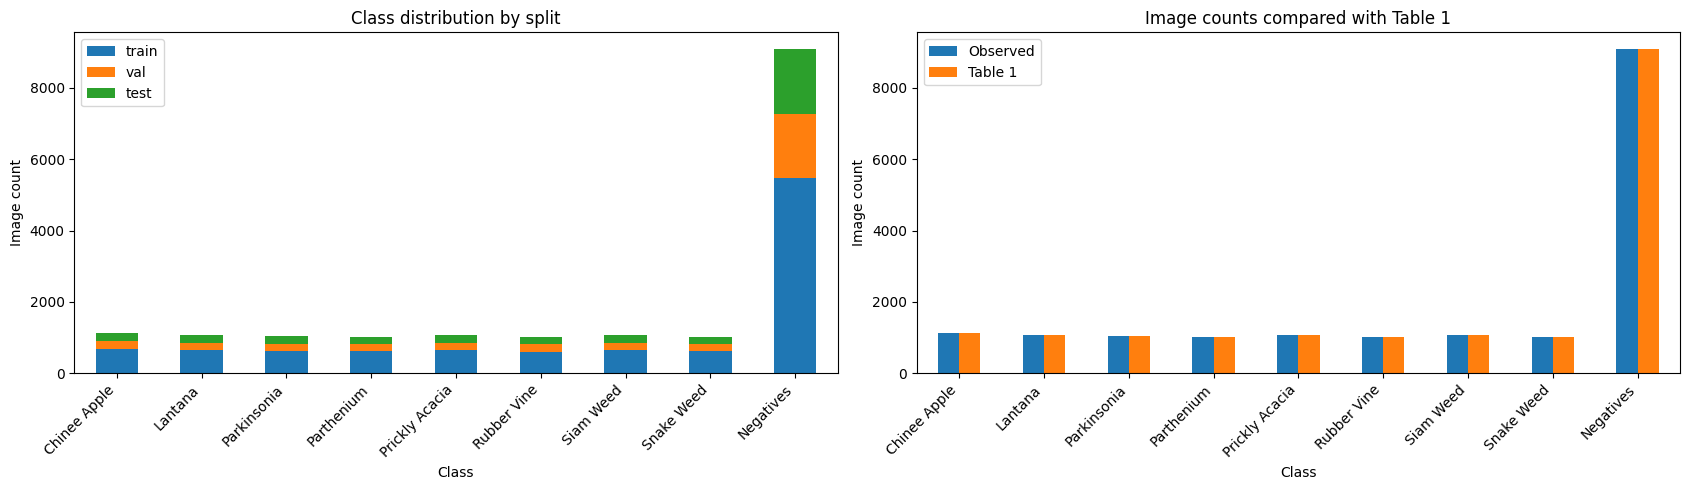

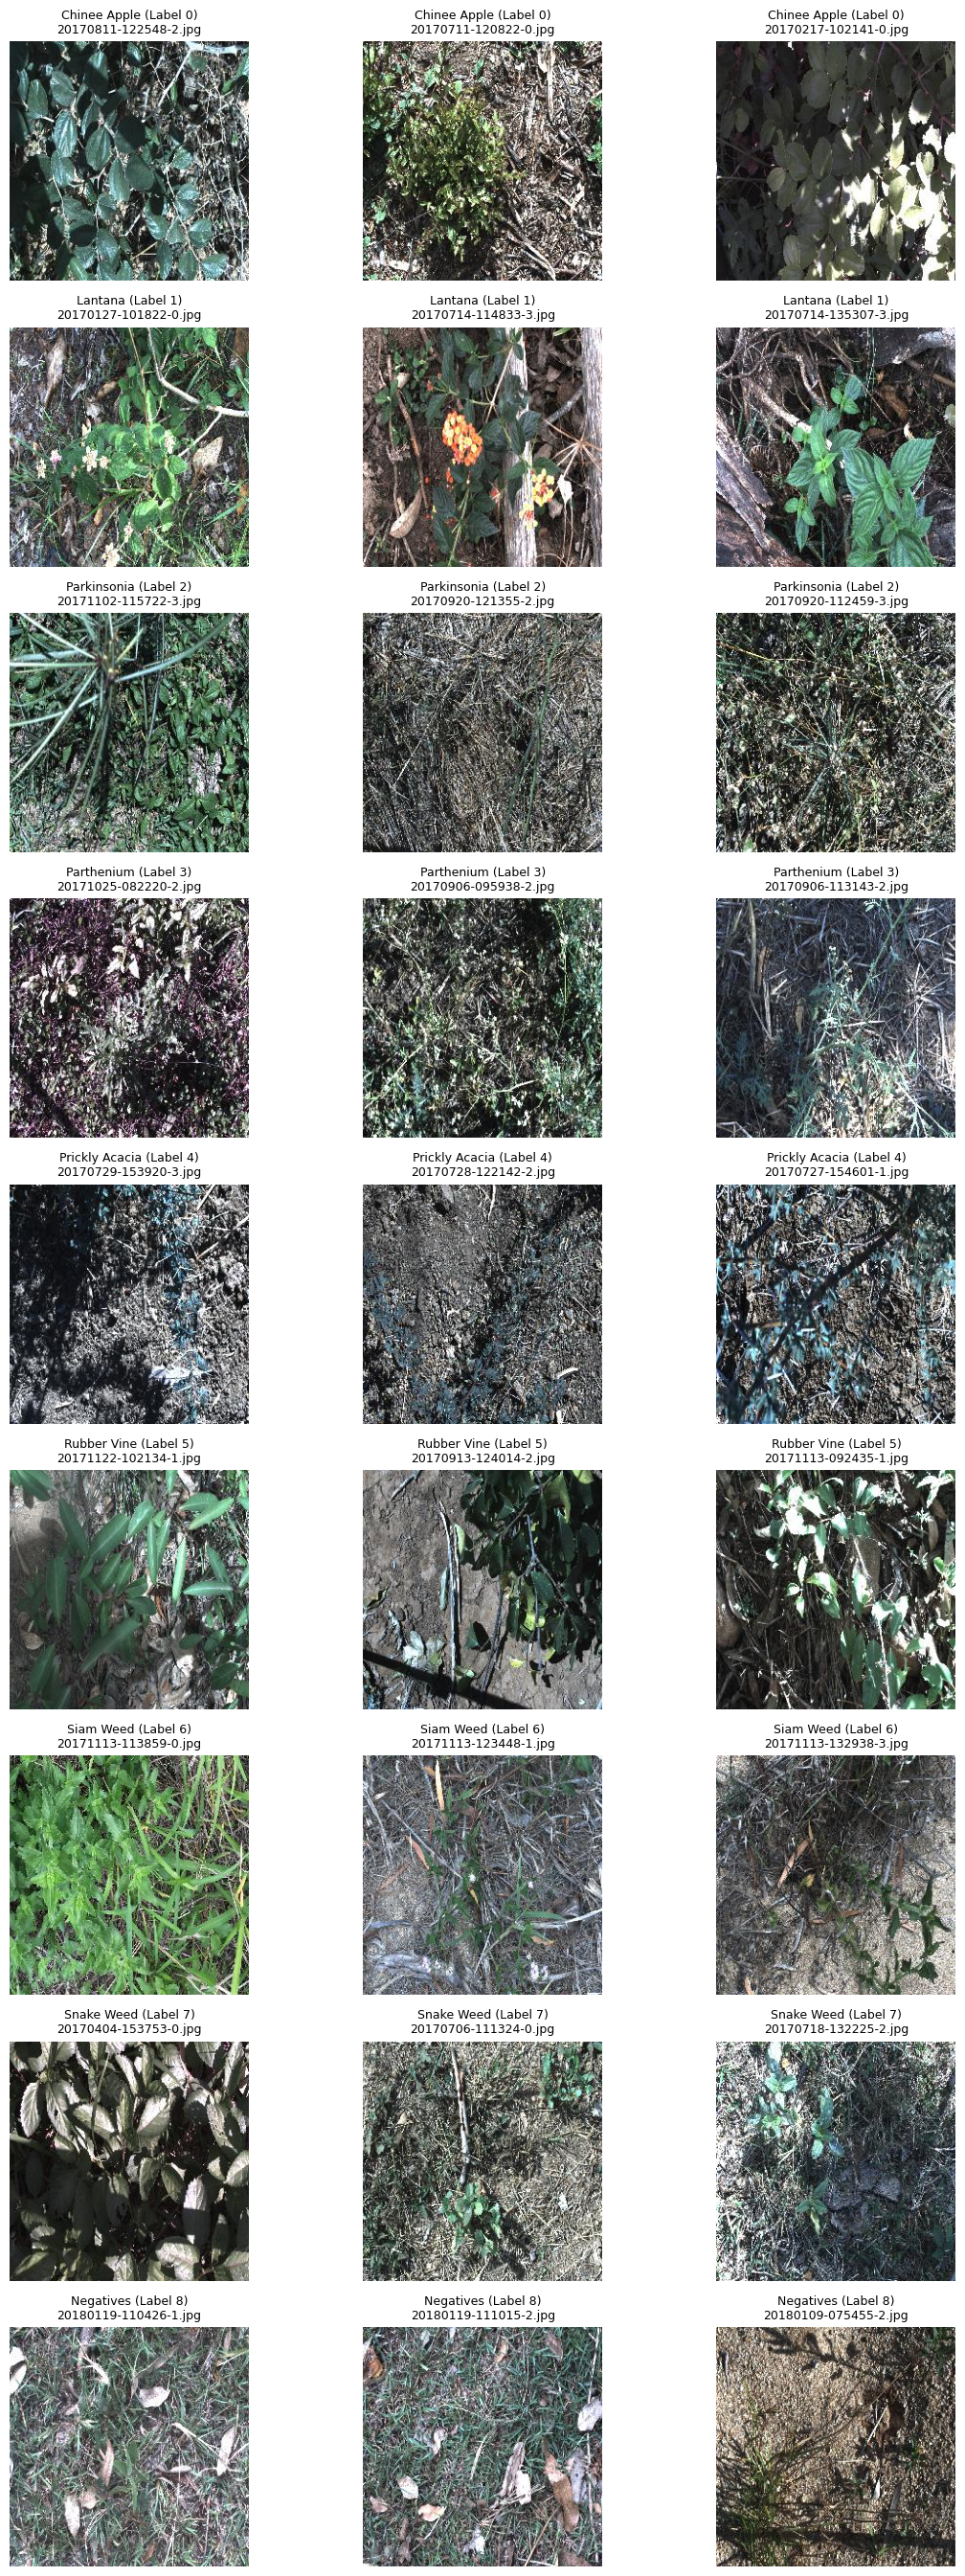

In [7]:
from pathlib import Path
import importlib
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import dataset

# Reload dataset.py after edits in this notebook session.
importlib.reload(dataset)
train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
split_stats = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)

# Preserve Label order 0-8, including classes absent from a split.
class_counts = pd.DataFrame(split_stats["per_class"]).reindex(range(dataset.NUM_CLASSES))
class_counts.index = pd.Index(dataset.CLASS_NAMES, name="Class")
class_counts["Total"] = class_counts.sum(axis=1)
display(class_counts)

# Table 1 counts reproduced in the lab README.md.
table1_counts = [1125, 1064, 1031, 1022, 1062, 1009, 1074, 1016, 9106]
comparison = pd.DataFrame({"Observed": class_counts["Total"], "Table 1": table1_counts})
comparison["Difference"] = comparison["Observed"] - comparison["Table 1"]
display(comparison)
if comparison["Difference"].eq(0).all():
    print("All 9 class counts match Table 1 (17,509 images).")
else:
    print("Counts differ from Table 1; check the source CSVs before training.")
negative_share = class_counts.loc["Negatives", "Total"] / class_counts["Total"].sum()
print(f"Negatives account for {negative_share:.2%}; the class distribution is imbalanced.")

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
class_counts[["train", "val", "test"]].plot.bar(stacked=True, ax=axes[0])
axes[0].set_title("Class distribution by split")
axes[0].set_ylabel("Image count")
comparison[["Observed", "Table 1"]].plot.bar(ax=axes[1])
axes[1].set_title("Image counts compared with Table 1")
axes[1].set_ylabel("Image count")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment("right")
fig.tight_layout()
plt.show()

# Show original training images with a fixed sampling seed.
images_per_class = 3
fig, axes = plt.subplots(dataset.NUM_CLASSES, images_per_class, figsize=(12, 27))
for label, class_name in enumerate(dataset.CLASS_NAMES):
    candidates = train_df.loc[train_df["Label"].eq(label)]
    if len(candidates) < images_per_class:
        raise ValueError(f"{class_name}: train has fewer than {images_per_class} images")
    samples = candidates.sample(n=images_per_class, random_state=42)
    for column, filename in enumerate(samples["Filename"]):
        ax = axes[label, column]
        with Image.open(Path(IMAGES_DIR) / filename) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(f"{class_name} (Label {label})\n{filename}", fontsize=9)
        ax.axis("off")
fig.tight_layout()
plt.show()


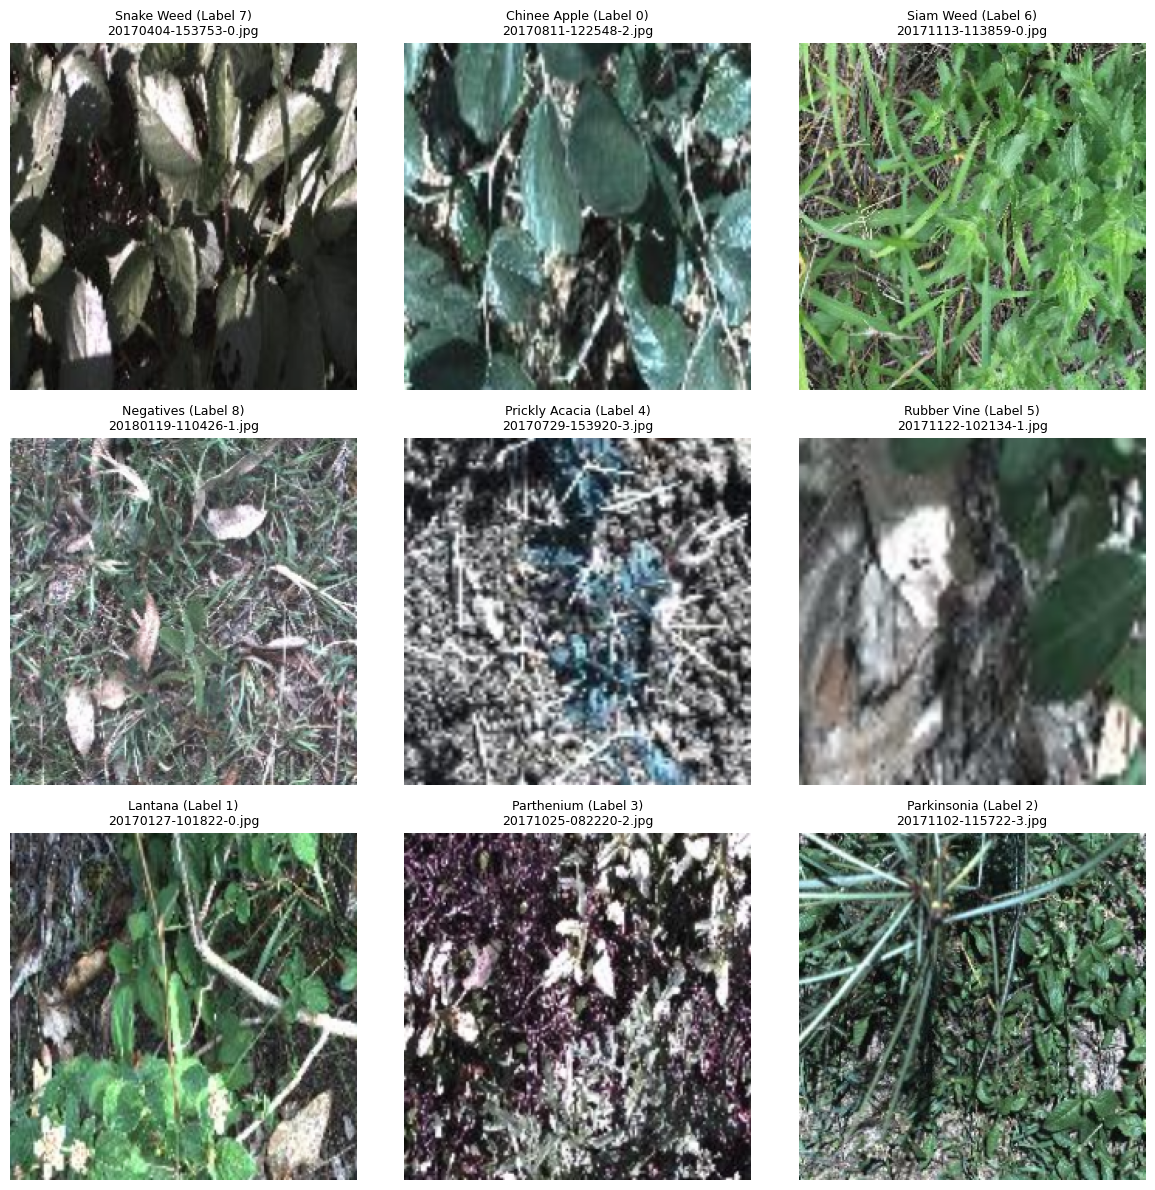

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Thiết bị: cuda; CE ban đầu = 2.2071; mốc ln(9) = 2.1972
Bước   1: CE = 2.19032, đúng 0%
Bước  25: CE = 0.73501, đúng 100%


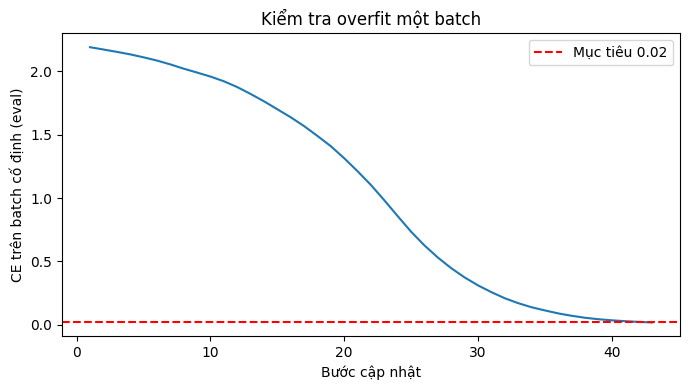

Kết quả: 43 bước; CE = 0.01909; đúng 100%
Các kiểm tra tự động đã đạt. Hãy xem thêm ảnh augmentation để xác nhận bằng mắt.


In [8]:
# Kiểm tra pipeline trước khi chạy thí nghiệm thật (GUIDE.md mục 1.3).
import math
import importlib
import torch
import dataset
import model as model_utils
import train

# Reload để notebook nhận các thay đổi vừa sửa trong file .py.
for module in (dataset, model_utils, train):
    importlib.reload(module)

SEED = 42
BACKBONE = "resnet50"
PRETRAINED = True  # Lần đầu cần Internet để tải trọng số ImageNet.
IMG_SIZE = 224
MAX_STEPS = 300
TARGET_LOSS = 0.02  # Ngưỡng thực hành cho loss gần 0.
train.set_seed(SEED)  # Cố định random, NumPy, PyTorch và cách tính trên GPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
evidence_dir = Path("curves")
evidence_dir.mkdir(parents=True, exist_ok=True)

# Chọn đúng một ảnh mỗi lớp từ TRAIN: batch nhỏ có đủ cả 9 nhãn.
# Chọn đủ lớp giúp phát hiện lỗi tốt hơn một batch chỉ có lớp Negatives.
small_df = pd.concat([
    train_df.loc[train_df["Label"].eq(label)].sample(n=1, random_state=SEED)
    for label in range(dataset.NUM_CLASSES)
], ignore_index=True)
small_loader = dataset.make_loader(
    small_df, IMAGES_DIR,
    dataset.build_transforms(train=True, img_size=IMG_SIZE, aug="basic"),
    batch_size=len(small_df), train=True, num_workers=0,
)
# num_workers=0 dễ chạy trên notebook/Windows; make_loader cũng đã seed worker
# cho trường hợp bạn tăng num_workers ở các thí nghiệm sau.
images, labels, filenames = next(iter(small_loader))
assert images.shape == (dataset.NUM_CLASSES, 3, IMG_SIZE, IMG_SIZE)
assert torch.isfinite(images).all(), "Ảnh chứa NaN hoặc vô cực"
assert labels.dtype == torch.long and set(labels.tolist()) == set(range(9))

# 4) Vẽ CHÍNH batch sau augmentation mà model sẽ học, kèm nhãn và tên file.
# Normalize tính (ảnh - mean)/std; đảo lại bằng ảnh * std + mean.
mean = torch.tensor(dataset.IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(dataset.IMAGENET_STD).view(3, 1, 1)
display_images = (images * std + mean).clamp(0, 1)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for index, ax in enumerate(axes.flat):
    label = int(labels[index])
    # Dataset phải giữ ảnh, nhãn, tên file từ cùng một dòng CSV.
    expected_label = int(small_df.set_index("Filename").loc[filenames[index], "Label"])
    assert label == expected_label, f"Nhãn lệch với CSV: {filenames[index]}"
    ax.imshow(display_images[index].permute(1, 2, 0).numpy())
    ax.set_title(f"{dataset.CLASS_NAMES[label]} (Label {label})\n{filenames[index]}", fontsize=9)
    ax.axis("off")
fig.tight_layout()
fig.savefig(evidence_dir / "pipeline_augmented.png", dpi=150)
plt.show()
# Vẫn cần nhìn ảnh để xác nhận crop có giữ vùng cây và nhãn có hợp lý.

# Model riêng cho kiểm tra; không dùng trọng số đã overfit cho thí nghiệm thật.
check_model = model_utils.build_model(
    BACKBONE, pretrained=PRETRAINED, num_classes=dataset.NUM_CLASSES,
    drop_rate=0.0, init="finetune",
).to(device)
images, labels = images.to(device), labels.to(device)
criterion = torch.nn.CrossEntropyLoss()  # CE thường, không smoothing hay trọng số lớp.

# 2) Đo head mới TRƯỚC khi học; eval tắt dropout và giữ thống kê BatchNorm.
check_model.eval()
with torch.no_grad():
    logits = check_model(images)
    assert logits.shape == (len(labels), dataset.NUM_CLASSES)
    initial_loss = criterion(logits, labels).item()
expected_loss = math.log(dataset.NUM_CLASSES)  # -ln(1/9) = ln(9).
print(f"Thiết bị: {device}; CE ban đầu = {initial_loss:.4f}; mốc ln(9) = {expected_loss:.4f}")
# Head ngẫu nhiên không nhất thiết chia xác suất đều, nên đây là mốc xấp xỉ.
# Không gán head bằng 0 để ép loss bằng 2.197: cần đo khởi tạo thật.
assert math.isfinite(initial_loss), "Loss ban đầu không hữu hạn"
assert abs(initial_loss - expected_loss) < 0.5, (
    "CE ban đầu lệch nhiều: kiểm tra logits, head, nhãn và chuẩn hoá ảnh."
)

# 3) Học lặp lại CÙNG tensor của một batch, không crop/lật lại mỗi bước.
# Bỏ weight decay và các cách làm khó việc nhớ batch để tìm lỗi cơ bản trước.
head_ids = {id(parameter) for parameter in check_model.get_classifier().parameters()}
optimizer = torch.optim.AdamW([
    {"params": [p for p in check_model.parameters() if id(p) not in head_ids], "lr": 1e-4},
    {"params": list(check_model.get_classifier().parameters()), "lr": 1e-3},
], weight_decay=0.0)
loss_history = []
check_model.train()  # Bật chế độ học cho bài kiểm tra toàn bộ model.
for step in range(1, MAX_STEPS + 1):
    optimizer.zero_grad(set_to_none=True)  # Xoá gradient (mức thay đổi cần học) bước trước.
    loss = criterion(check_model(images), labels)
    assert torch.isfinite(loss).item(), f"Loss không hữu hạn ở bước {step}"
    loss.backward()  # Tính mức thay đổi cần áp dụng cho từng trọng số.
    optimizer.step()  # Cập nhật trọng số để giảm loss.

    # Đo lại SAU cập nhật ở eval: kiểm tra cả cách model sẽ dùng khi dự đoán.
    check_model.eval()
    with torch.no_grad():
        predictions = check_model(images)
        measured_loss = criterion(predictions, labels).item()
        accuracy = (predictions.argmax(dim=1) == labels).float().mean().item()
    assert math.isfinite(measured_loss), f"Loss eval không hữu hạn ở bước {step}"
    loss_history.append(measured_loss)
    check_model.train()
    if step == 1 or step % 25 == 0:
        print(f"Bước {step:3d}: CE = {measured_loss:.5f}, đúng {accuracy:.0%}")
    if measured_loss <= TARGET_LOSS and accuracy == 1.0:
        break

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(loss_history) + 1), loss_history)
ax.axhline(TARGET_LOSS, color="red", linestyle="--", label=f"Mục tiêu {TARGET_LOSS}")
ax.set(xlabel="Bước cập nhật", ylabel="CE trên batch cố định (eval)", title="Kiểm tra overfit một batch")
ax.legend()
fig.tight_layout()
fig.savefig(evidence_dir / "pipeline_overfit.png", dpi=150)
plt.show()
print(f"Kết quả: {len(loss_history)} bước; CE = {measured_loss:.5f}; đúng {accuracy:.0%}")
assert measured_loss <= TARGET_LOSS and accuracy == 1.0, (
    "Chưa overfit được batch: kiểm tra gradient, LR, dữ liệu và model trước khi train thật."
)

# Giải phóng model kiểm tra; seed lại trước khi tạo model của thí nghiệm thật.
del optimizer, loss, logits, predictions, check_model, images, labels
if torch.cuda.is_available():
    torch.cuda.empty_cache()
train.set_seed(SEED)
print("Các kiểm tra tự động đã đạt. Hãy xem thêm ảnh augmentation để xác nhận bằng mắt.")


## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [9]:
# Bước 1: chỉ thay backbone; giữ nguyên dữ liệu, seed và công thức nền.
from dataclasses import replace
from pathlib import Path
import importlib
import json
import pandas as pd
import torch
import timm
import train
import model as model_utils
import losses
from IPython.display import display

for module in (model_utils, losses, train):
    importlib.reload(module)
from train import Config, run

# 5 backbone: ResNet, ConvNeXt, transformer (DeiT) và 2 mạng nhẹ.
# B01 cũng là backbone mốc; T00 sẽ dùng công thức nền này ở bước sau.
BACKBONES = ["resnet50", "convnext_tiny", "deit_small_patch16_224",
             "efficientnet_b0", "mobilenetv3_large_100"]
BASE_CONFIG = Config(
    seed=0, fold=0, init="finetune", img_size=224, aug="basic",
    epochs=12, batch_size=64, lr_backbone=1e-4, lr_head=1e-3,
    weight_decay=0.05, warmup_epochs=1.0, loss="ce", amp=True,
    num_workers=0 if __import__("os").name == "nt" else 2,
    images_dir=IMAGES_DIR, labels_dir=LABELS_DIR,
    save_test_predictions=False,  # Bước 1 tuyệt đối không dự đoán test.
)
# Nếu thiếu bộ nhớ, giảm batch_size ở BASE_CONFIG cho TẤT CẢ backbone.
# GMAC = tỷ phép nhân-cộng/ảnh; params_M = triệu tham số.
# macro-F1 coi mỗi lớp quan trọng như nhau; top-1 là tỉ lệ đoán đúng.
results_path = Path("results.xlsx")

def save_backbone_table(table):
    # Chỉ cập nhật sheet Backbones, giữ các sheet của bước khác nếu đã có.
    options = {"mode": "a", "if_sheet_exists": "replace"} if results_path.exists() else {"mode": "w"}
    with pd.ExcelWriter(results_path, engine="openpyxl", **options) as writer:
        table.to_excel(writer, sheet_name="Backbones", index=False)
        writer.sheets["Backbones"].freeze_panes = "A2"
    table.to_csv("backbones.csv", index=False)

backbone_rows = []
for index, backbone in enumerate(BACKBONES, start=1):
    cfg = replace(BASE_CONFIG, exp_id=f"B{index:02d}", backbone=backbone)
    folder = train.run_dir(cfg)
    summary_path = folder / "summary.json"
    if summary_path.exists():
        # Chạy lại ô sẽ đọc kết quả đã hoàn tất, tránh train lại tốn thời gian.
        saved_config = json.loads((folder / "config.json").read_text(encoding="utf-8"))
        from dataclasses import asdict
        differences = [key for key, value in asdict(cfg).items() if saved_config.get(key) != value]
        if differences:
            raise ValueError(f"{cfg.exp_id}: cấu hình đã đổi {differences}; dùng out_dir mới")
        if saved_config.get("timm_version") != timm.__version__ or saved_config.get("torch_version") != torch.__version__:
            raise ValueError(f"{cfg.exp_id}: phiên bản thư viện khác lần trước; dùng out_dir mới")
        result = json.loads(summary_path.read_text(encoding="utf-8"))
        print(f"Đọc kết quả đã có: {cfg.exp_id} - {backbone}")
    else:
        # Mỗi lần chạy lưu config, history, checkpoint, logits và dự đoán val.
        result = run(cfg)
    backbone_rows.append(result)
    backbones_df = pd.DataFrame(backbone_rows)
    save_backbone_table(backbones_df)  # Lưu sau từng model để giữ kết quả nếu phiên bị ngắt.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

display(backbones_df.sort_values("val_macro_f1", ascending=False))

# Chọn model có F1 cao nhất, khi hoà ưu tiên model nhanh hơn.
ranked = backbones_df.sort_values(
    ["val_macro_f1", "train_seconds_per_epoch", "GMAC"], ascending=[False, True, True])
best = ranked.iloc[0]
selected_rows = [best]
reasons = [f"{best.backbone}: macro-F1 val cao nhất ({best.val_macro_f1:.4f}), "
           f"top-1={best.val_top1:.4f}; train {best.train_seconds_per_epoch:.1f} s/epoch."]

# Giữ thêm một model nhanh hơn nếu F1 chỉ kém tối đa 0.01 (1 điểm phần trăm).
# Đây là ngưỡng thực dụng, không phải kết luận chênh lệch có ý nghĩa thống kê.
F1_TOLERANCE = 0.01
alternatives = ranked[
    (ranked.exp_id != best.exp_id)
    & (ranked.val_macro_f1 >= best.val_macro_f1 - F1_TOLERANCE)
    & (ranked.train_seconds_per_epoch < best.train_seconds_per_epoch)
].sort_values(["train_seconds_per_epoch", "val_macro_f1"], ascending=[True, False])
if not alternatives.empty:
    efficient = alternatives.iloc[0]
    selected_rows.append(efficient)
    reasons.append(f"{efficient.backbone}: F1={efficient.val_macro_f1:.4f}, "
                   f"kém {best.val_macro_f1 - efficient.val_macro_f1:.4f}, "
                   f"nhưng train {efficient.train_seconds_per_epoch:.1f} s/epoch "
                   f"so với {best.train_seconds_per_epoch:.1f}; GMAC={efficient.GMAC:.3f}.")

# Biến này dùng để chọn backbone cho bước 2; chưa dùng kết quả test.
selected_backbones = [row.backbone for row in selected_rows]
selection = {"selected_backbones": selected_backbones, "reasons": reasons,
             "f1_tolerance": F1_TOLERANCE,
             "note": "Một seed: cần kiểm chứng nhiều seed ở vòng cuối; độ trễ mới đo sơ bộ."}
Path("backbone_selection.json").write_text(
    json.dumps(selection, ensure_ascii=False, indent=2), encoding="utf-8")
for reason in reasons:
    print(reason)
print("Backbone đi tiếp:", selected_backbones)
print(selection["note"])


train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         644   215   215
Snake Weed        609   203   204
Negatives        5463  1821  1822
Tổng: 17,509 ảnh; giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)


B01 epoch 1/12: F1=0.1844, top1=0.5516, train=44.0s
B01 epoch 2/12: F1=0.6187, top1=0.7315, train=49.5s
B01 epoch 3/12: F1=0.7089, top1=0.7872, train=46.8s
B01 epoch 4/12: F1=0.7350, top1=0.8092, train=47.2s
B01 epoch 5/12: F1=0.7564, top1=0.8223, train=47.2s
B01 epoch 6/12: F1=0.7678, top1=0.8343, train=47.4s
B01 epoch 7/12: F1=0.7874, top1=0.8455, train=47.3s
B01 epoch 8/12: F1=0.8010, top1=0.8563, train=47.5s
B01 epoch 9/12: F1=0.7993, top1=0.8558, train=47.2s
B01 epoch 10/12: F1=0.8060, top1=0.8598, train=47.2s
B01 epoch 11/12: F1=0.8055, top1=0.8598, train=47.5s
B01 epoch 12/12: F1=0.8010, top1=0.8549, train=47.3s
train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         644   215   215
Snake Weed        609   2

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

...

model.safetensors: downloading bytes:           |  0.00B            

Unsupported operator aten::hardswish_ encountered 21 time(s)
Unsupported operator aten::add encountered 10 time(s)
Unsupported operator aten::mean encountered 8 time(s)
Unsupported operator aten::hardsigmoid encountered 8 time(s)
Unsupported operator aten::mul encountered 8 time(s)


B05 epoch 1/12: F1=0.3758, top1=0.5456, train=30.4s
B05 epoch 2/12: F1=0.4492, top1=0.6175, train=22.9s
B05 epoch 3/12: F1=0.5437, top1=0.6727, train=22.1s
B05 epoch 4/12: F1=0.5908, top1=0.7107, train=22.1s
B05 epoch 5/12: F1=0.6091, top1=0.7224, train=22.7s
B05 epoch 6/12: F1=0.6446, top1=0.7461, train=22.5s
B05 epoch 7/12: F1=0.6604, top1=0.7609, train=22.7s
B05 epoch 8/12: F1=0.6753, top1=0.7646, train=22.5s
B05 epoch 9/12: F1=0.6643, top1=0.7618, train=22.5s
B05 epoch 10/12: F1=0.7027, top1=0.7843, train=22.7s
B05 epoch 11/12: F1=0.6446, top1=0.7532, train=22.5s
B05 epoch 12/12: F1=0.6832, top1=0.7726, train=22.7s


,exp_id,backbone,weight_tag,params_M,GMAC,img_size,epochs,seed,best_epoch,val_macro_f1,val_top1,train_seconds_per_epoch,latency_batch1_ms,notes
1,B02,convnext_tiny,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,11,0.972635,0.978292,55.918243,12.661387,"Latency: 1 measurement, FP32, excludes preproc..."
2,B03,deit_small_patch16_224,deit_small_patch16_224.fb_in1k,21.669129,4.250294,224,12,0,12,0.949364,0.964296,38.627209,15.024515,"Latency: 1 measurement, FP32, excludes preproc..."
0,B01,resnet50,resnet50.a1_in1k,23.526473,4.109483,224,12,0,10,0.805997,0.859754,47.171951,7.797176,"Latency: 1 measurement, FP32, excludes preproc..."
3,B04,efficientnet_b0,efficientnet_b0.ra_in1k,4.019077,0.398084,224,12,0,12,0.752173,0.819480,31.850880,9.824670,"Latency: 1 measurement, FP32, excludes preproc..."
4,B05,mobilenetv3_large_100,mobilenetv3_large_100.ra_in1k,4.213561,0.224168,224,12,0,10,0.702706,0.784347,23.208036,7.527052,"Latency: 1 measurement, FP32, excludes preproc..."


convnext_tiny: macro-F1 val cao nhất (0.9726), top-1=0.9783; train 55.9 s/epoch.
Backbone đi tiếp: ['convnext_tiny']
Một seed: cần kiểm chứng nhiều seed ở vòng cuối; độ trễ mới đo sơ bộ.


## Bước 2 — Công thức huấn luyện (4 trục)

- Chọn backbone đứng đầu ở bước 1, giữ đúng tag trọng số. `T00` là công thức nền **trên backbone này**; `B01` vẫn là mốc ResNet ở bảng Backbones.
- So sánh augmentation (biến đổi ảnh), loss (đo sai số), sampler (cách lấy mẫu) và EMA (làm mượt trọng số).
- `T01`–`T08` mỗi lần chỉ thay một kỹ thuật so với `T00`; `T09` kết hợp lựa chọn tốt nhất của các trục.
- Mỗi lần chạy 12 epoch nếu bước 1 dùng 12 epoch: tổng 10 lần train ở bước này. Nếu T00 đã chạy hoàn tất thì đọc lại kết quả.
- Chọn trên **val**, lưu bảng `Training` và `training_selection.json`. Một seed chưa đủ để kết luận chênh lệch nhỏ là chắc chắn.


In [10]:
# Bước 2: nạp các file .py vừa sửa SAU KHI bước 1 đã chạy xong.
import importlib
import dataset
import model as model_utils
import losses
import train
import inference
import benchmark
import experiments
from IPython.display import display

for module in (dataset, model_utils, losses, train, inference, benchmark, experiments):
    importlib.reload(module)

# Mọi lần huấn luyện đều đi qua train.run(Config(...)).
# Hàm này lưu sau từng thí nghiệm, rồi chọn cấu hình theo macro-F1 val.
# Không tự giảm epoch/batch giữa các thí nghiệm để giữ so sánh công bằng.
training_df = experiments.training_step(
    images_dir=IMAGES_DIR, labels_dir=LABELS_DIR,
    out_dir="runs", pred_dir="predictions", workbook="results.xlsx",
)
display(training_df.sort_values("val_macro_f1", ascending=False))
print(experiments.read_json("training_selection.json")["note"])


train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         644   215   215
Snake Weed        609   203   204
Negatives        5463  1821  1822
Tổng: 17,509 ảnh; giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}


Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


T00 epoch 1/12: F1=0.8107, top1=0.8575, train=56.6s
T00 epoch 2/12: F1=0.8855, top1=0.9060, train=55.5s
T00 epoch 3/12: F1=0.9159, top1=0.9377, train=55.3s
T00 epoch 4/12: F1=0.9306, top1=0.9477, train=55.1s
T00 epoch 5/12: F1=0.9462, top1=0.9577, train=55.1s
T00 epoch 6/12: F1=0.9616, top1=0.9700, train=54.9s
T00 epoch 7/12: F1=0.9470, top1=0.9612, train=54.8s
T00 epoch 8/12: F1=0.9537, top1=0.9632, train=54.3s
T00 epoch 9/12: F1=0.9709, top1=0.9774, train=54.1s
T00 epoch 10/12: F1=0.9699, top1=0.9763, train=54.2s
T00 epoch 11/12: F1=0.9726, top1=0.9783, train=53.8s
T00 epoch 12/12: F1=0.9714, top1=0.9774, train=53.8s
train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         644   215   215
Snake Weed        609   2

Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


T01 epoch 1/12: F1=0.7991, top1=0.8469, train=57.5s
T01 epoch 2/12: F1=0.9090, top1=0.9274, train=56.7s
T01 epoch 3/12: F1=0.9425, top1=0.9540, train=56.7s
T01 epoch 4/12: F1=0.9352, top1=0.9500, train=57.5s
T01 epoch 5/12: F1=0.9433, top1=0.9540, train=57.3s
T01 epoch 6/12: F1=0.9268, top1=0.9409, train=57.2s
T01 epoch 7/12: F1=0.9510, top1=0.9594, train=56.2s
T01 epoch 8/12: F1=0.9478, top1=0.9594, train=56.3s
T01 epoch 9/12: F1=0.9513, top1=0.9617, train=56.7s
T01 epoch 10/12: F1=0.9663, top1=0.9743, train=56.5s
T01 epoch 11/12: F1=0.9601, top1=0.9692, train=56.3s
T01 epoch 12/12: F1=0.9634, top1=0.9720, train=55.7s
train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         644   215   215
Snake Weed        609   2

...

T08 epoch 1/12: F1=0.8560, top1=0.8900, train=56.6s
T08 epoch 2/12: F1=0.9111, top1=0.9257, train=56.0s
T08 epoch 3/12: F1=0.9361, top1=0.9472, train=56.0s
T08 epoch 4/12: F1=0.9235, top1=0.9429, train=56.3s
T08 epoch 5/12: F1=0.9410, top1=0.9540, train=56.3s
T08 epoch 6/12: F1=0.9524, top1=0.9609, train=56.0s
T08 epoch 7/12: F1=0.9493, top1=0.9623, train=55.8s
T08 epoch 8/12: F1=0.9585, top1=0.9674, train=56.0s
T08 epoch 9/12: F1=0.9622, top1=0.9709, train=55.9s
T08 epoch 10/12: F1=0.9696, top1=0.9766, train=55.9s
T08 epoch 11/12: F1=0.9682, top1=0.9757, train=55.6s
T08 epoch 12/12: F1=0.9718, top1=0.9789, train=55.4s
train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         644   215   215
Snake Weed        609   2

Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


T09 epoch 1/12: F1=0.8628, top1=0.8932, train=57.1s
T09 epoch 2/12: F1=0.9439, top1=0.9560, train=57.1s
T09 epoch 3/12: F1=0.9562, top1=0.9669, train=56.6s
T09 epoch 4/12: F1=0.9603, top1=0.9694, train=56.9s
T09 epoch 5/12: F1=0.9679, top1=0.9754, train=56.6s
T09 epoch 6/12: F1=0.9682, top1=0.9766, train=56.5s
T09 epoch 7/12: F1=0.9736, top1=0.9809, train=56.5s
T09 epoch 8/12: F1=0.9726, top1=0.9797, train=55.8s
T09 epoch 9/12: F1=0.9740, top1=0.9803, train=55.8s
T09 epoch 10/12: F1=0.9717, top1=0.9786, train=55.9s
T09 epoch 11/12: F1=0.9743, top1=0.9809, train=55.5s
T09 epoch 12/12: F1=0.9738, top1=0.9809, train=55.5s
Chọn T02: F1=0.9763; Δ=+0.0036 so với T00
Kết hợp T09 cải thiện so với T00: +0.0016


,exp_id,backbone,weight_tag,params_M,GMAC,img_size,epochs,seed,best_epoch,val_macro_f1,val_top1,train_seconds_per_epoch,latency_batch1_ms,notes,axis,changed,delta_vs_T00,f1_chinee_apple,f1_snake_weed
2,T02,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,10,0.976267,0.982291,55.353046,14.025372,"Latency: 1 measurement, FP32, excludes preproc...",B,RandAugment: biến đổi ảnh ngẫu nhiên,0.003632,0.962306,0.939698
9,T09,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,11,0.974259,0.980863,56.327903,12.578548,Kết hợp các trục cải thiện,combination,T02+T07,0.001624,NaN,NaN
7,T07,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,12,0.972911,0.978292,55.651108,13.557456,"Latency: 1 measurement, FP32, excludes preproc...",F,"EMA: làm mượt trọng số, decay=0.99",0.000276,0.959091,0.943210
0,T00,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,11,0.972635,0.978292,54.789255,12.451942,"Latency: 1 measurement, FP32, excludes preproc...",baseline,Công thức nền trên backbone đã chọn,0.000000,NaN,NaN
8,T08,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,12,0.971827,0.978863,55.984727,12.305761,"Latency: 1 measurement, FP32, excludes preproc...",B,CutMix: trộn vùng ảnh cùng nhãn,-0.000808,0.957111,0.936275
6,T06,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,12,0.971599,0.978006,54.705285,13.604880,"Latency: 1 measurement, FP32, excludes preproc...",D,Lấy mẫu cân bằng lớp,-0.001036,0.952809,0.938875
3,T03,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,12,0.971182,0.978006,55.580050,13.272592,"Latency: 1 measurement, FP32, excludes preproc...",C,Làm mềm nhãn 0.1,-0.001453,0.954751,0.923833
4,T04,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,10,0.970382,0.978578,54.341313,13.358074,"Latency: 1 measurement, FP32, excludes preproc...",C,"Focal: chú ý ảnh khó, gamma=2",-0.002253,0.955752,0.933661
1,T01,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,10,0.966349,0.974293,56.729489,11.747543,"Latency: 1 measurement, FP32, excludes preproc...",B,Thêm đổi màu ảnh,-0.006286,0.932735,0.928747
5,T05,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224,12,0,11,0.964956,0.971151,54.901078,13.115857,"Latency: 1 measurement, FP32, excludes preproc...",C,CE có trọng số nghịch số ảnh train,-0.007679,0.942731,0.911215


Một seed: Δ là quan sát sơ bộ; so với std ở bước 4, chưa kết luận chắc chắn.


## Bước 3 — Suy luận và độ trễ (4 cách ngoài mốc)
Không huấn luyện lại, dùng checkpoint tốt nhất được chọn ở bước 2, chỉ đánh giá trên **val**:

| Mã | Cách suy luận |
|---|---|
| I00 | Một vùng cắt giữa — mốc |
| I01 | Ảnh gốc + lật ngang; trung bình xác suất |
| I02 | 4 góc + giữa (5 crop); trung bình xác suất |
| I03 | Ảnh gốc + lật ngang; trung bình điểm số trước softmax |
| I04 | Hiệu chỉnh xác suất bằng một nhiệt độ T khớp trên val |

Softmax biến điểm số của các lớp thành xác suất. Hiệu chỉnh T thay đổi độ tự tin, giữ nguyên lớp dự đoán.
Độ trễ đo 50 lần sau 10 lượt làm nóng, đồng bộ GPU, ở batch 1 và 32. Không tính đọc/resize/normalize ảnh; có tính tạo view và gộp dự đoán.
`p95` nghĩa là 95% lần đo có thời gian không vượt giá trị đó. ECE đo mức lệch giữa độ tự tin và tỉ lệ đúng.
Lưu sheet `Inference`, `Latency`, ảnh `curves/inference_tradeoff.png` và `inference_selection.json`.
ECE/NLL val sau khớp T đo trên chính tập khớp, nên chưa đại diện cho dữ liệu mới; bước 4 mới kiểm tra trên test.


In [11]:
# Bước 3: đọc checkpoint đã có, tuyệt đối không mở tập test.
# Chọn kiểu view theo macro-F1 val; nếu hoà thì ưu tiên p95 thấp hơn.
# Chốt dùng calibration (hiệu chỉnh xác suất); vòng cuối khớp T riêng trên val mỗi seed.
inference_df = experiments.inference_step(
    workbook="results.xlsx", iters=50, batches=(1, 32),
)
display(inference_df.sort_values("val_macro_f1", ascending=False))
print(experiments.read_json("inference_selection.json"))


I00: F1=0.9763, ECE=0.0071, p95=12.98 ms
I01: F1=0.9760, ECE=0.0084, p95=26.69 ms
I02: F1=0.9776, ECE=0.0059, p95=62.47 ms
I03: F1=0.9760, ECE=0.0097, p95=28.28 ms
I04: F1=0.9763, ECE=0.0040, p95=14.43 ms
Chọn cách suy luận: fivecrop ; sẽ khớp T trên val cho từng seed.
ECE 1-view trước/sau: 0.0071 / 0.0040


,exp_id,method,description,checkpoint,K,val_macro_f1,val_top1,val_ece,val_nll,temperature,p50_ms,p95_ms,p99_ms,images_per_s,throughput_batch,relative_cost
2,I02,fivecrop,"5 crop, gộp xác suất",runs/T02/seed0/best.pt,5,0.977607,0.983148,0.005851,0.072268,1.000000,59.974823,62.465815,63.300790,42.845358,32,5.111768
0,I00,identity,1 view - mốc,runs/T02/seed0/best.pt,1,0.976267,0.982291,0.007136,0.078427,1.000000,11.732697,12.975182,13.864114,214.725680,32,1.000000
4,I04,identity,Hiệu chỉnh xác suất bằng nhiệt độ T,runs/T02/seed0/best.pt,1,0.976267,0.982291,0.003978,0.070488,1.399392,12.748788,14.431525,14.998277,211.678751,32,1.086603
1,I01,hflip_prob,"Lật ngang, gộp xác suất",runs/T02/seed0/best.pt,2,0.975985,0.982005,0.008449,0.075892,1.000000,24.636424,26.694725,28.276718,106.594040,32,2.099809
3,I03,hflip_logit,"Lật ngang, gộp điểm số trước softmax",runs/T02/seed0/best.pt,2,0.975985,0.982005,0.009697,0.077136,1.000000,26.336487,28.280155,28.875942,105.489232,32,2.244709


{'method': 'fivecrop', 'source_id': 'I02', 'calibrate': True, 'training_config': {'exp_id': 'T02', 'seed': 0, 'fold': 0, 'backbone': 'convnext_tiny.in12k_ft_in1k', 'init': 'finetune', 'drop_rate': 0.0, 'img_size': 224, 'aug': 'randaug', 'sampler': None, 'mix': None, 'mix_alpha': 1.0, 'loss': 'ce', 'label_smoothing': 0.0, 'focal_gamma': 2.0, 'class_weight_beta': None, 'epochs': 12, 'batch_size': 64, 'lr_backbone': 0.0001, 'lr_head': 0.001, 'weight_decay': 0.05, 'warmup_epochs': 1.0, 'ema_decay': None, 'amp': True, 'num_workers': 2, 'images_dir': 'data/images', 'labels_dir': 'data/labels', 'out_dir': 'runs', 'pred_dir': 'predictions', 'save_test_predictions': False}, 'val_macro_f1': 0.9776071618035309, 'note': 'T khớp trên val; ECE/NLL val sau khớp là số trong mẫu, test chỉ đánh giá ở bước 4.'}


## Bước 4 — Chung kết: 3 seed, test một lần mỗi cấu hình/seed
**Chạy ô dưới sau khi hoàn tất bước 2 và 3. Chạy ô này sẽ bắt đầu đánh giá test.**

1. Lưu cố định cấu hình train và cách suy luận đã chọn trên val vào `runs/final_selection_lock.json`.
2. Huấn luyện `F01` (cấu hình tốt nhất) và `T00` (công thức nền cùng backbone) với seed 0, 1, 2. T00 seed 0 đã hoàn tất ở bước 2 sẽ được đọc lại.
3. Train chỉ đánh giá val; sau đó F01 khớp T trên val. Mỗi cấu hình/seed chỉ đi qua test một lượt, lưu cả trước/sau hiệu chỉnh từ cùng dự đoán.
4. Lưu `predictions/F01_seed<k>_test.csv`, `T00_seed<k>_test.csv` và `F01uncal_seed<k>_test.csv`. Chạy các ô `eval.py` phía dưới để đối chiếu số liệu.
5. Tổng hợp mean/std (trung bình/độ dao động giữa seed), F1 từng lớp, ma trận nhầm lẫn và so Δ với std.

Khi chạy lại ô, chương trình đọc `final_outputs.npz`, không dự đoán test lại. Nếu phiên ngắt giữa lượt test trước khi lưu xong, code dừng và yêu cầu ghi nhận sự cố; không tự thử lại test.
Sau khi đã mở test, không đổi cấu hình để chọn kết quả tốt hơn.


In [12]:
# Bước 4: cấu hình đã được chốt hoàn toàn từ val ở bước 2 và 3.
# Có thể mất thời gian: 3 seed cho F01 và T00 (T00 seed 0 dùng lại).
# train.run KHÔNG dự đoán test ở đây; experiments.final_step thực hiện
# một lượt test đúng cách suy luận đã chốt, rồi lưu cache để không chạy lại.
final_df = experiments.final_step(
    seeds=(0, 1, 2), workbook="results.xlsx",
)
display(final_df)


train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         644   215   215
Snake Weed        609   203   204
Negatives        5463  1821  1822
Tổng: 17,509 ảnh; giao giữa các tập: {'train_val': 0, 'train_test': 0, 'val_test': 0}


Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


F01 epoch 1/12: F1=0.8496, top1=0.8889, train=56.8s
F01 epoch 2/12: F1=0.9150, top1=0.9354, train=55.7s
F01 epoch 3/12: F1=0.9226, top1=0.9412, train=55.9s
F01 epoch 4/12: F1=0.9298, top1=0.9486, train=55.5s
F01 epoch 5/12: F1=0.9545, top1=0.9657, train=55.4s
F01 epoch 6/12: F1=0.9538, top1=0.9643, train=55.8s
F01 epoch 7/12: F1=0.9527, top1=0.9626, train=55.2s
F01 epoch 8/12: F1=0.9701, top1=0.9757, train=55.1s
F01 epoch 9/12: F1=0.9624, top1=0.9732, train=55.3s
F01 epoch 10/12: F1=0.9763, top1=0.9823, train=55.3s
F01 epoch 11/12: F1=0.9743, top1=0.9809, train=54.9s
F01 epoch 12/12: F1=0.9746, top1=0.9814, train=55.0s
F01 seed=0: test F1=0.9734, top1=0.9795
Đọc lần chạy đã có: T00, seed=0
T00 seed=0: test F1=0.9715, top1=0.9772
train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia 

Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


F01 epoch 1/12: F1=0.8770, top1=0.9049, train=56.1s
F01 epoch 2/12: F1=0.9168, top1=0.9332, train=56.0s
F01 epoch 3/12: F1=0.9296, top1=0.9446, train=55.9s
F01 epoch 4/12: F1=0.9174, top1=0.9337, train=55.7s
F01 epoch 5/12: F1=0.9322, top1=0.9486, train=55.4s
F01 epoch 6/12: F1=0.9607, top1=0.9697, train=55.5s
F01 epoch 7/12: F1=0.9629, top1=0.9717, train=55.2s
F01 epoch 8/12: F1=0.9651, top1=0.9734, train=54.9s
F01 epoch 9/12: F1=0.9586, top1=0.9686, train=55.0s
F01 epoch 10/12: F1=0.9661, top1=0.9749, train=55.1s
F01 epoch 11/12: F1=0.9694, top1=0.9763, train=54.9s
F01 epoch 12/12: F1=0.9709, top1=0.9777, train=55.0s
F01 seed=1: test F1=0.9723, top1=0.9780
train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         6

...

Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


F01 epoch 1/12: F1=0.8670, top1=0.9006, train=56.7s
F01 epoch 2/12: F1=0.9138, top1=0.9312, train=55.7s
F01 epoch 3/12: F1=0.8608, top1=0.8923, train=55.9s
F01 epoch 4/12: F1=0.9109, top1=0.9386, train=55.7s
F01 epoch 5/12: F1=0.9356, top1=0.9517, train=55.4s
F01 epoch 6/12: F1=0.9362, top1=0.9494, train=55.2s
F01 epoch 7/12: F1=0.9608, top1=0.9703, train=55.4s
F01 epoch 8/12: F1=0.9564, top1=0.9674, train=55.1s
F01 epoch 9/12: F1=0.9628, top1=0.9726, train=55.2s
F01 epoch 10/12: F1=0.9637, top1=0.9732, train=55.1s
F01 epoch 11/12: F1=0.9702, top1=0.9771, train=54.6s
F01 epoch 12/12: F1=0.9710, top1=0.9777, train=54.4s
F01 seed=2: test F1=0.9724, top1=0.9780
train: 10,501 ảnh (59.97%)
val: 3,501 ảnh (20.00%)
test: 3,507 ảnh (20.03%)
                train   val  test
Chinee Apple      675   225   226
Lantana           637   213   213
Parkinsonia       618   206   207
Parthenium        613   204   205
Prickly Acacia    637   212   213
Rubber Vine       605   202   202
Siam Weed         6

Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


T00 epoch 1/12: F1=0.8786, top1=0.9089, train=56.1s
T00 epoch 2/12: F1=0.8914, top1=0.9177, train=55.6s
T00 epoch 3/12: F1=0.8857, top1=0.9075, train=55.2s
T00 epoch 4/12: F1=0.9203, top1=0.9397, train=55.3s
T00 epoch 5/12: F1=0.8982, top1=0.9183, train=55.0s
T00 epoch 6/12: F1=0.9596, top1=0.9692, train=54.5s
T00 epoch 7/12: F1=0.9553, top1=0.9646, train=54.6s
T00 epoch 8/12: F1=0.9597, top1=0.9697, train=54.3s
T00 epoch 9/12: F1=0.9604, top1=0.9697, train=54.2s
T00 epoch 10/12: F1=0.9659, top1=0.9734, train=53.7s
T00 epoch 11/12: F1=0.9667, top1=0.9743, train=53.7s
T00 epoch 12/12: F1=0.9687, top1=0.9760, train=53.8s
T00 seed=2: test F1=0.9767, top1=0.9803
F01 test macro-F1 = 0.9727 ± 0.0006
T00 test macro-F1 = 0.9738 ± 0.0026
Δ=-0.0011; std lớn hơn=0.0026. Chưa có cải thiện vượt std quan sát.


,exp_id,backbone,weight_tag,params_M,GMAC,img_size,epochs,seed,best_epoch,val_macro_f1,...,val_test_f1_gap,p95_ms,n_seeds,val_macro_f1_std,val_top1_std,test_macro_f1_std,test_top1_std,test_ece_std,test_ece_uncal_std,p95_ms_std
0,F01,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224.0,12.0,0,10.0,0.977607,...,0.004212,66.413595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T00,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224.0,12.0,0,11.0,0.972635,...,0.001143,13.065130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F01,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224.0,12.0,1,12.0,0.971642,...,0.000657,65.755829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T00,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224.0,12.0,1,10.0,0.969798,...,0.003321,12.892722,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F01,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224.0,12.0,2,12.0,0.970981,...,0.001376,60.873421,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,T00,convnext_tiny.in12k_ft_in1k,convnext_tiny.in12k_ft_in1k,27.827049,4.469676,224.0,12.0,2,12.0,0.968750,...,0.007919,13.045900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,F01,NaN,NaN,NaN,NaN,NaN,NaN,all,NaN,0.973410,...,NaN,64.347615,3.0,0.00365,0.002982,0.000617,0.000823,0.001802,0.000511,3.026662
7,T00,NaN,NaN,NaN,NaN,NaN,NaN,all,NaN,0.970394,...,NaN,13.001251,3.0,0.00201,0.001143,0.002647,0.001671,0.001734,0.001734,0.094479


In [13]:
# Tính lại từ CSV đã lưu; ô này KHÔNG chạy model hoặc dự đoán test lần nữa.
# Dùng sys.executable để gọi đúng Python của kernel, kể cả khi chạy trên Windows.
import subprocess
import sys

for tag in ("F01", "T00"):
    subprocess.run([
        sys.executable, str(experiments.REPO / "eval.py"), "score",
        "--pred", f"predictions/{tag}_seed*_test.csv",
        "--test-csv", str(Path(LABELS_DIR) / "test_subset0.csv"),
        "--labels", str(Path(LABELS_DIR) / "labels.csv"),
        "--tag", tag, "--out", "eval_out",
    ], check=True)


### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9785 ± 0.0008 |
| macro-F1 | 0.9727 ± 0.0006 |
| balanced accuracy | 0.9703 ± 0.0005 |
| ECE (15 bin) | 0.0056 ± 0.0018 |
| NLL | 0.0680 ± 0.0030 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.971 ± 0.006 | 0.926 ± 0.022 | 0.948 ± 0.009 | 226 |
| Lantana | 0.984 ± 0.011 | 0.975 ± 0.003 | 0.980 ± 0.005 | 213 |
| Parkinsonia | 0.973 ± 0.010 | 0.984 ± 0.003 | 0.978 ± 0.005 | 207 |
| Parthenium | 0.998 ± 0.003 | 0.963 ± 0.012 | 0.980 ± 0.005 | 205 |
| Prickly acacia | 0.948 ± 0.003 | 0.969 ± 0.005 | 0.958 ± 0.004 | 213 |
| Rubber vine | 0.985 ± 0.000 | 0.980 ± 0.010 | 0.983 ± 0.005 | 202 |
| Siam weed | 0.980 ± 0.016 | 0.994 ± 0.003 | 0.987 ± 0.008 | 215 |
| Snake weed | 0.956 ± 0.001 | 0.954 ± 0.020 | 0.955 ± 0.011 | 204 |
| Negative | 0.983 ± 0.001 | 0.988 ± 0.001 | 0.985 ± 0.001 | 1822 |

Đã lưu kết quả vào eval_out/F01_*
### T00 (3 seed: [0, 1, 2]; 3507 

In [14]:
# Tự chấm phần I từ file dự đoán. Trước/sau calibration đều từ một lượt test.
# Final-val giúp đối chiếu khoảng cách F1 giữa val và test.
final_batch1 = final_df.loc[(final_df.exp_id == "F01") & (final_df.kind == "seed"), "p95_ms"]
subprocess.run([
    sys.executable, str(experiments.REPO / "eval.py"), "grade",
    "--final", "predictions/F01_seed*_test.csv",
    "--baseline", "predictions/T00_seed*_test.csv",
    "--uncal", "predictions/F01uncal_seed*_test.csv",
    "--final-val", "predictions/F01_seed*_val.csv",
    "--latency-p95-ms", str(float(final_batch1.max())),
    "--test-csv", str(Path(LABELS_DIR) / "test_subset0.csv"),
    "--labels", str(Path(LABELS_DIR) / "labels.csv"), "--out", "eval_out",
], check=True)


## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 97.85% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 0 | 5 | final 0.9727, mốc 0.9738, Δ=-0.0011, s=0.0026 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 92.6% (mốc 88.5%), Snake Weed 95.4% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | 1 | 1 | trước 0.0084, sau 0.0056 |
| I4b | Chênh macro-F1 val/test <= 0.02 | 1 | 1 | val 0.9734, test 0.9727, chênh 0.0007 |
| I5 | Cấu hình thời gian thực | 2 | 2 | p95 = 66.4 ms (ngân sách 100 ms), đo đúng cách |

**Tổng các ý đã chấm: 15 / 20** (phần I tối đa 20).

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).


CompletedProcess(args=['/usr/bin/python3', '/kaggle/working/K4-DAY02-BuiVietAnh-2A202602611/eval.py', 'grade', '--final', 'predictions/F01_seed*_test.csv', '--baseline', 'predictions/T00_seed*_test.csv', '--uncal', 'predictions/F01uncal_seed*_test.csv', '--final-val', 'predictions/F01_seed*_val.csv', '--latency-p95-ms', '66.41359495006327', '--test-csv', 'data/labels/test_subset0.csv', '--labels', 'data/labels/labels.csv', '--out', 'eval_out'], returncode=0)

## Bước 5 — Tổng hợp, kiểm tra và xuất sản phẩm
Chạy sau khi bước 1–4 hoàn tất. Bước này **không huấn luyện và không dự đoán test lại**.

1. Đối chiếu mỗi số liệu trong bảng với log và CSV dự đoán bằng hàm của `eval.py`. Thiếu file hoặc số liệu lệch thì dừng và báo rõ.
2. Hoàn thiện đủ 7 sheet: `Backbones`, `Training`, `Inference`, `Final`, `PerClass`, `Latency`, `Summary`.
3. Xếp top 10 theo **macro-F1 val**, giữ đơn vị chi phí/độ trễ, thêm mean ± std (trung bình và độ dao động giữa seed).
4. Định dạng Excel: cố định hàng tiêu đề, bộ lọc, 4 chữ số thập phân, tô dòng F1 tốt nhất.
5. Vẽ lại biểu đồ từ log, mỗi exp_id/seed một ảnh; tạo bảng/ảnh lỗi từ dự đoán đã lưu.
6. Xuất `results.xlsx`, `report.md`, `README.md`, `curves/`, `predictions/`, `code/`, `eval_out/` và log nhỏ vào thư mục nộp.


In [15]:
# Bước 5: chỉ tổng hợp bằng chứng đã lưu ở các bước trước.
import importlib
import reporting
from IPython.display import display

importlib.reload(reporting)

# Mặc định xuất vào submissions/2A202602611_BuiVietAnh/.
# Nếu thiếu kết quả, hàm sẽ dừng và chỉ rõ cần hoàn tất bước nào.
# Không chạy model trên test thêm lần nào ở ô này.
products = reporting.deliverables_step(workbook="results.xlsx")
display(products["summary"])
print("Thư mục sản phẩm:", products["submission_dir"])
print("Số lần chạy đã đối chiếu log/CSV:", products["verified_runs"])
print("File ZIP:", products["archive"])


Bước 5 hoàn tất. Bộ file nộp: /kaggle/working/K4-DAY02-BuiVietAnh-2A202602611/submissions/2A202602611_BuiVietAnh
Đủ 7 sheet; số liệu khớp CSV/log. Không huấn luyện hoặc dự đoán test thêm.
Xem report.generated.md; report.md/README.md đã tồn tại được giữ nguyên.
File nén để nộp (không có dữ liệu/checkpoint lớn): /kaggle/working/K4-DAY02-BuiVietAnh-2A202602611/submissions/2A202602611_BuiVietAnh/submission_bundle.zip


,rank,exp_id,source,backbone,n_seeds,val_macro_f1,val_macro_f1_std,val_top1,params_M,GMAC_estimate,train_seconds_per_epoch,latency_batch1_ms,p95_ms
0,1,I02,Inference,convnext_tiny.in12k_ft_in1k,1,0.977607,NaN,0.983148,27.827049,22.348381,NaN,NaN,62.465815
1,2,I00,Inference,convnext_tiny.in12k_ft_in1k,1,0.976267,NaN,0.982291,27.827049,4.469676,NaN,NaN,12.975182
2,3,I04,Inference,convnext_tiny.in12k_ft_in1k,1,0.976267,NaN,0.982291,27.827049,4.469676,NaN,NaN,14.431525
3,4,T02,Training,convnext_tiny.in12k_ft_in1k,1,0.976267,NaN,0.982291,27.827049,4.469676,55.353046,14.025372,NaN
4,5,I01,Inference,convnext_tiny.in12k_ft_in1k,1,0.975985,NaN,0.982005,27.827049,8.939353,NaN,NaN,26.694725
5,6,I03,Inference,convnext_tiny.in12k_ft_in1k,1,0.975985,NaN,0.982005,27.827049,8.939353,NaN,NaN,28.280155
6,7,T09,Training,convnext_tiny.in12k_ft_in1k,1,0.974259,NaN,0.980863,27.827049,4.469676,56.327903,12.578548,NaN
7,8,F01,Final,convnext_tiny.in12k_ft_in1k,3,0.973410,0.00365,0.979720,27.827049,22.348381,55.413057,NaN,64.347615
8,9,T07,Training,convnext_tiny.in12k_ft_in1k,1,0.972911,NaN,0.978292,27.827049,4.469676,55.651108,13.557456,NaN
9,10,B02,Backbones,convnext_tiny,1,0.972635,NaN,0.978292,27.827049,4.469676,55.918243,12.661387,NaN


Thư mục sản phẩm: /kaggle/working/K4-DAY02-BuiVietAnh-2A202602611/submissions/2A202602611_BuiVietAnh
Số lần chạy đã đối chiếu log/CSV: 20
File ZIP: /kaggle/working/K4-DAY02-BuiVietAnh-2A202602611/submissions/2A202602611_BuiVietAnh/submission_bundle.zip
